# MSCS 634 – Lab Assignment 1

**Name:** Oishani Ganguly 
**Course Title:** MSCS-634: Advanced Big Data and Data Mining  
**Lab Assignment Title:** Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis Using Python in Jupyter Notebook  

---

## Dataset: Superstore Sales (Kaggle)
Source: https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting  
This dataset contains retail sales transactions from a US-based superstore, including order details, product categories, regions, ship modes, customer segments, and sales figures. It is well-suited for exploring sales trends, category breakdowns, and preprocessing workflows.

---
## Step 1: Data Collection

In [61]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [62]:
# Load the dataset
df = pd.read_csv('train.csv')

# Parse date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Dataset shape: 9800 rows × 18 columns
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [63]:
# Display the first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.00,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.00,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.00,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37


---
## Step 2: Data Visualization

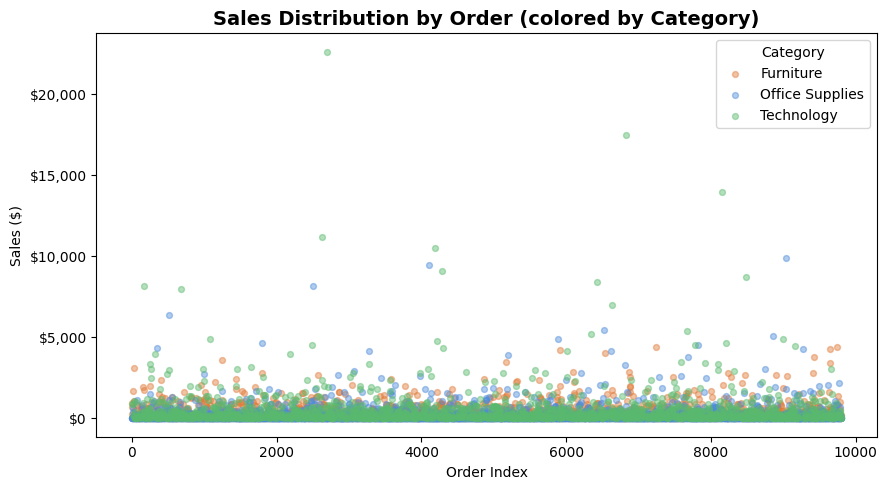

Insight: Technology orders (green) tend to cluster at higher sales values compared to Office Supplies (blue), which are densely packed near zero. A few high-value outliers are visible across all categories.


In [64]:
# --- Visualization 1: Scatter Plot — Row ID vs Sales (proxy for order sequence vs sales value)
fig, ax = plt.subplots(figsize=(9, 5))

colors = {'Furniture': '#e07b39', 'Office Supplies': '#4e8cd9', 'Technology': '#5aba6e'}
for category, group in df.groupby('Category'):
    ax.scatter(group.index, group['Sales'], label=category,
               alpha=0.45, s=18, color=colors[category])

ax.set_title('Sales Distribution by Order (colored by Category)', fontsize=14, fontweight='bold')
ax.set_xlabel('Order Index')
ax.set_ylabel('Sales ($)')
ax.legend(title='Category')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('viz_scatter.png', dpi=150)
plt.show()
print('Insight: Technology orders (green) tend to cluster at higher sales values compared to '
      'Office Supplies (blue), which are densely packed near zero. '
      'A few high-value outliers are visible across all categories.')

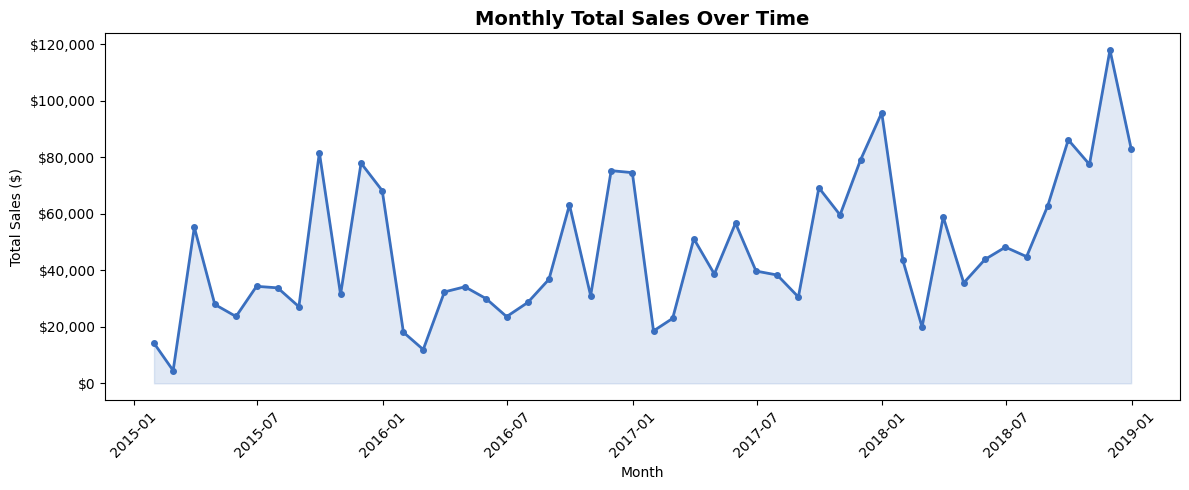

Insight: Sales show a clear seasonal pattern, spiking in Q4 (Oct–Dec) each year — consistent with holiday shopping behavior. There is also a general upward trend from 2015 to 2018.


In [65]:
# --- Visualization 2: Line Plot — Monthly Sales Trend Over Time
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_sales['Order Date'], monthly_sales['Sales'],
        color='#3a6fbf', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_sales['Order Date'], monthly_sales['Sales'],
                alpha=0.15, color='#3a6fbf')
ax.set_title('Monthly Total Sales Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('viz_line.png', dpi=150)
plt.show()
print('Insight: Sales show a clear seasonal pattern, spiking in Q4 (Oct–Dec) each year — '
      'consistent with holiday shopping behavior. There is also a general upward trend '
      'from 2015 to 2018.')

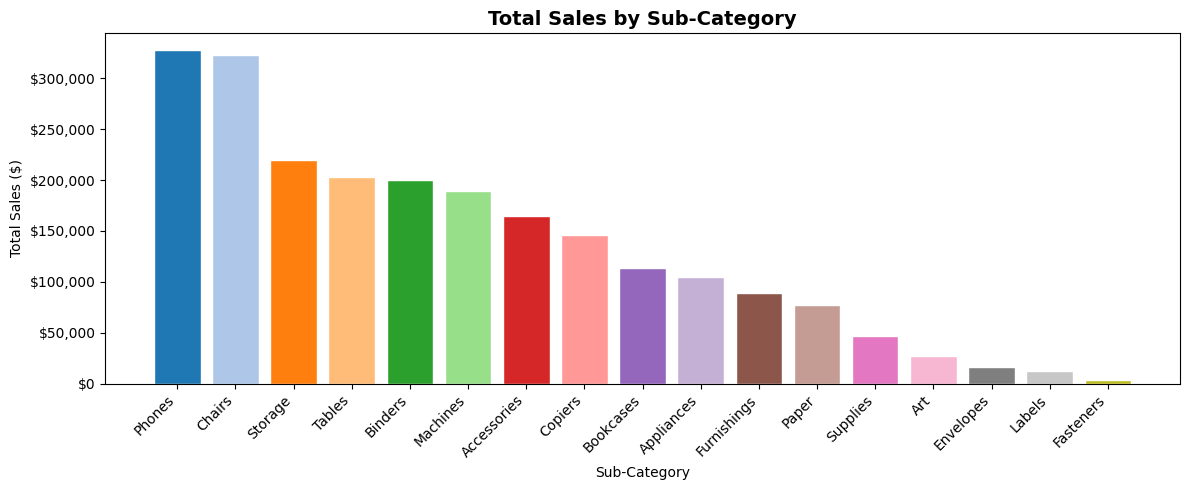

Insight: Phones and Chairs are the top-selling sub-categories, while Fasteners and Labels generate the least revenue. Technology sub-categories dominate the top spots.


In [66]:
# --- Visualization 3: Bar Chart — Total Sales by Sub-Category
sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(sub_sales.index, sub_sales.values,
              color=plt.cm.tab20.colors[:len(sub_sales)], edgecolor='white')
ax.set_title('Total Sales by Sub-Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Sub-Category')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('viz_bar.png', dpi=150)
plt.show()
print('Insight: Phones and Chairs are the top-selling sub-categories, while Fasteners '
      'and Labels generate the least revenue. Technology sub-categories dominate the top spots.')

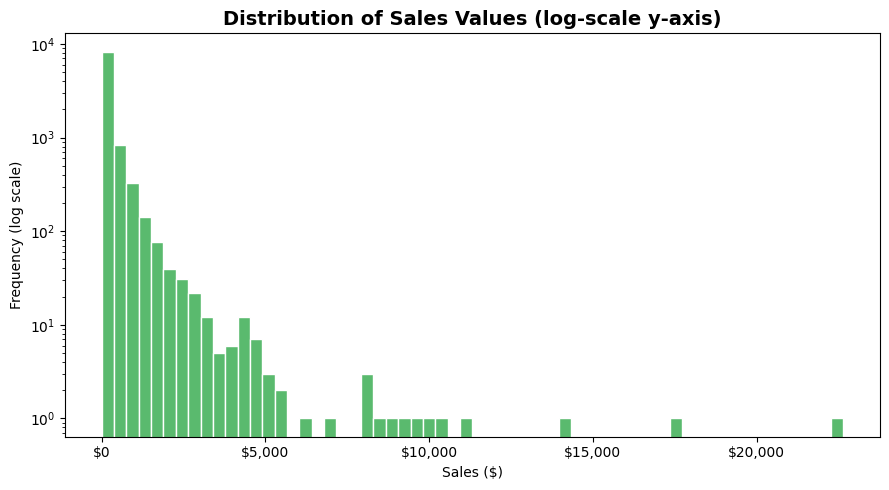

Insight: Sales are heavily right-skewed — the vast majority of orders are under $500, but a long tail of high-value orders (some exceeding $10,000) pulls the mean significantly above the median.


In [67]:
# --- Visualization 4: Histogram — Distribution of Sales Values
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Sales'], bins=60, color='#5aba6e', edgecolor='white', log=True)
ax.set_title('Distribution of Sales Values (log-scale y-axis)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Frequency (log scale)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('viz_hist.png', dpi=150)
plt.show()
print('Insight: Sales are heavily right-skewed — the vast majority of orders are under $500, '
      'but a long tail of high-value orders (some exceeding $10,000) pulls the mean '
      'significantly above the median.')

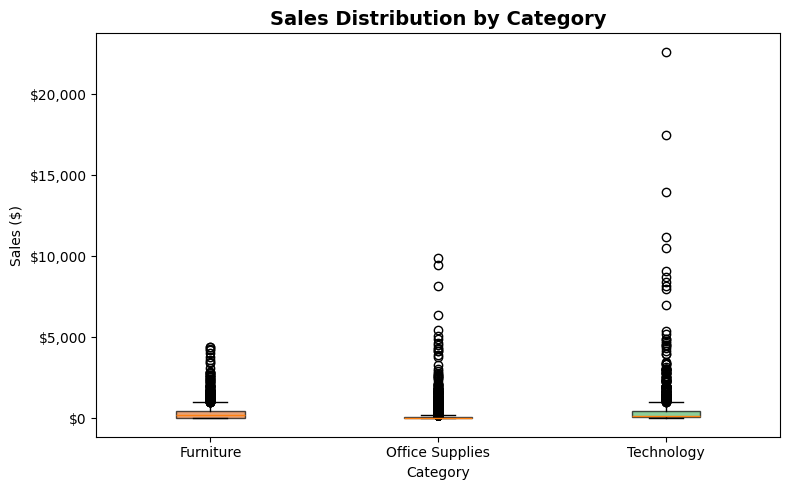

Insight: All three categories have a low median with many high-value outliers above the upper whisker. Technology has the widest spread and highest outliers, while Office Supplies are the most consistently low-value.


In [68]:
# --- Visualization 5: Box Plot — Sales Distribution by Category
categories = [df[df['Category'] == c]['Sales'].values for c in df['Category'].unique()]
cat_labels  = list(df['Category'].unique())

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(categories, labels=cat_labels, patch_artist=True, notch=False)
box_colors = ['#e07b39', '#4e8cd9', '#5aba6e']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Sales Distribution by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('viz_box.png', dpi=150)
plt.show()
print('Insight: All three categories have a low median with many high-value outliers above the '
      'upper whisker. Technology has the widest spread and highest outliers, while '
      'Office Supplies are the most consistently low-value.')

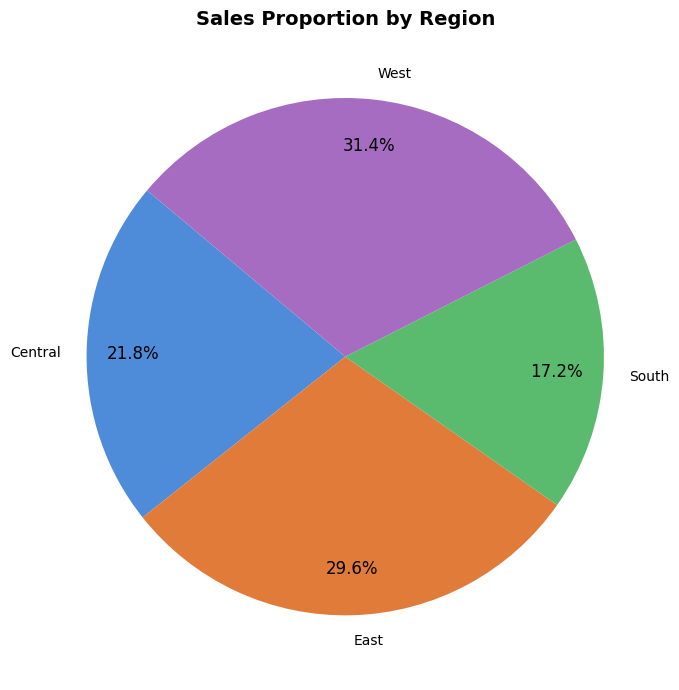

Insight: The West region leads in total sales share, followed closely by the East. The Central region lags behind, suggesting a potential area for growth or targeted marketing efforts.


In [69]:
# --- Visualization 6: Pie Chart — Sales Proportion by Region
region_sales = df.groupby('Region')['Sales'].sum()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    region_sales.values,
    labels=region_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#4e8cd9', '#e07b39', '#5aba6e', '#a56cc1'],
    pctdistance=0.82
)
for text in autotexts:
    text.set_fontsize(12)
ax.set_title('Sales Proportion by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_pie.png', dpi=150)
plt.show()
print('Insight: The West region leads in total sales share, followed closely by the East. '
      'The Central region lags behind, suggesting a potential area for growth or '
      'targeted marketing efforts.')

---
## Step 3: Data Preprocessing

### 3.1 – Handling Missing Values

In [70]:
# --- Before: Detect and report missing values
print('=== Missing Values BEFORE Handling ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else 'No missing values detected.')
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')
df.head(3)

=== Missing Values BEFORE Handling ===
             Missing Count  Missing %
Postal Code             11       0.11

Total missing cells: 11


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.00,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62


In [71]:
# Introduce synthetic missing values to demonstrate handling techniques
df_missing = df.copy()
np.random.seed(42)

# Randomly null ~5% of Sales values
null_idx_sales = np.random.choice(df_missing.index, size=int(len(df_missing) * 0.05), replace=False)
df_missing.loc[null_idx_sales, 'Sales'] = np.nan

# Randomly null ~3% of Ship Mode values
null_idx_ship = np.random.choice(df_missing.index, size=int(len(df_missing) * 0.03), replace=False)
df_missing.loc[null_idx_ship, 'Ship Mode'] = np.nan

print('Missing values after injection:')
print(df_missing.isnull().sum()[df_missing.isnull().sum() > 0])

Missing values after injection:
Ship Mode      294
Postal Code     11
Sales          490
dtype: int64


In [72]:
# --- Handle missing values
df_clean = df_missing.copy()

# Numeric: fill Sales NaN with column mean
sales_mean = df_clean['Sales'].mean()
df_clean['Sales'].fillna(sales_mean, inplace=True)

# Categorical: fill Ship Mode NaN with mode (most frequent value)
ship_mode_mode = df_clean['Ship Mode'].mode()[0]
df_clean['Ship Mode'].fillna(ship_mode_mode, inplace=True)

print('=== Missing Values AFTER Handling ===')
print(f'Remaining missing cells: {df_clean.isnull().sum().sum()}')
print(f'Sales NaN filled with mean: ${sales_mean:.2f}')
print(f'Ship Mode NaN filled with mode: "{ship_mode_mode}"')
df_clean[['Sales', 'Ship Mode']].head(10)

=== Missing Values AFTER Handling ===
Remaining missing cells: 11
Sales NaN filled with mean: $229.38
Ship Mode NaN filled with mode: "Standard Class"


,Sales,Ship Mode
0,261.96,Second Class
1,731.94,Second Class
2,14.62,Second Class
3,229.38,Standard Class
4,22.37,Standard Class
5,48.86,Standard Class
6,7.28,Standard Class
7,907.15,Standard Class
8,18.50,Standard Class
9,114.90,Standard Class


### 3.2 – Outlier Detection and Removal

In [73]:
# --- IQR Outlier Detection on Sales
Q1  = df_clean['Sales'].quantile(0.25)
Q3  = df_clean['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['Sales'] < lower_bound) | (df_clean['Sales'] > upper_bound)]

print(f'Q1  = ${Q1:.2f}')
print(f'Q3  = ${Q3:.2f}')
print(f'IQR = ${IQR:.2f}')
print(f'Lower Bound = ${lower_bound:.2f}')
print(f'Upper Bound = ${upper_bound:.2f}')
print(f'\nOutliers detected: {len(outliers)} rows ({len(outliers)/len(df_clean)*100:.1f}%)')
outliers[['Order ID', 'Category', 'Sub-Category', 'Sales']].head(10)

Q1  = $18.26
Q3  = $229.38
IQR = $211.12
Lower Bound = $-298.43
Upper Bound = $546.07

Outliers detected: 973 rows (9.9%)


,Order ID,Category,Sub-Category,Sales
1,CA-2017-152156,Furniture,Chairs,731.94
7,CA-2015-115812,Technology,Phones,907.15
10,CA-2015-115812,Furniture,Tables,1706.18
11,CA-2015-115812,Technology,Phones,911.42
16,CA-2015-105893,Office Supplies,Storage,665.88
24,CA-2016-106320,Furniture,Tables,1044.63
27,US-2016-150630,Furniture,Bookcases,3083.43
35,CA-2017-117590,Technology,Phones,1097.54
54,CA-2017-105816,Technology,Phones,1029.95
67,CA-2015-106376,Office Supplies,Art,1113.02


In [74]:
# Remove outliers
df_no_outliers = df_clean[(df_clean['Sales'] >= lower_bound) & (df_clean['Sales'] <= upper_bound)].copy()

print(f'Rows before outlier removal: {len(df_clean)}')
print(f'Rows after  outlier removal: {len(df_no_outliers)}')
print(f'Removed: {len(df_clean) - len(df_no_outliers)} rows')
print(f'\nSales stats BEFORE removal:  mean=${df_clean["Sales"].mean():.2f}, max=${df_clean["Sales"].max():.2f}')
print(f'Sales stats AFTER  removal:  mean=${df_no_outliers["Sales"].mean():.2f}, max=${df_no_outliers["Sales"].max():.2f}')

Rows before outlier removal: 9800
Rows after  outlier removal: 8827
Removed: 973 rows

Sales stats BEFORE removal:  mean=$229.38, max=$22638.48
Sales stats AFTER  removal:  mean=$105.69, max=$546.06


### 3.3 – Data Reduction

In [75]:
# --- Before Data Reduction
print('=== Dataset BEFORE Data Reduction ===')
print(f'Shape: {df_no_outliers.shape}')
print(f'Columns: {list(df_no_outliers.columns)}')
df_no_outliers.head(3)

=== Dataset BEFORE Data Reduction ===
Shape: (8827, 18)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.00,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.00,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,229.38


In [76]:
# --- Apply Data Reduction ---

# 1. Sampling: take a random 50% sample
df_sampled = df_no_outliers.sample(frac=0.50, random_state=42).reset_index(drop=True)

# 2. Dimension elimination: drop low-analysis-value identifier columns
cols_to_drop = ['Row ID', 'Order ID', 'Customer ID', 'Product ID',
                'Customer Name', 'Product Name', 'Postal Code', 'Country']
df_reduced = df_sampled.drop(columns=cols_to_drop)

print('=== Dataset AFTER Data Reduction ===')
print(f'Shape: {df_reduced.shape}  (was {df_no_outliers.shape})')
print(f'Remaining columns: {list(df_reduced.columns)}')
df_reduced.head()

=== Dataset AFTER Data Reduction ===
Shape: (4414, 10)  (was (8827, 18))
Remaining columns: ['Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'City', 'State', 'Region', 'Category', 'Sub-Category', 'Sales']


,Order Date,Ship Date,Ship Mode,Segment,City,State,Region,Category,Sub-Category,Sales
0,2017-04-12,2017-04-16,Standard Class,Consumer,Springfield,Virginia,South,Furniture,Tables,343.92
1,2016-11-15,2016-11-19,Standard Class,Home Office,Harrisonburg,Virginia,South,Furniture,Furnishings,39.96
2,2018-04-20,2018-04-24,Standard Class,Consumer,Chicago,Illinois,Central,Furniture,Furnishings,14.56
3,2018-08-18,2018-08-25,Standard Class,Consumer,Lakewood,Ohio,East,Office Supplies,Binders,10.78
4,2016-12-31,2017-01-02,Second Class,Corporate,Detroit,Michigan,Central,Office Supplies,Binders,116.40


### 3.4 – Data Scaling and Discretization

In [77]:
# --- Before Scaling
print('=== Sales Column BEFORE Scaling ===')
print(df_reduced[['Sales']].describe())
df_reduced[['Sales']].head()

=== Sales Column BEFORE Scaling ===
        Sales
count 4414.00
mean   103.79
std    122.22
min      0.56
25%     15.72
50%     45.94
75%    161.94
max    546.06


,Sales
0,343.92
1,39.96
2,14.56
3,10.78
4,116.40


In [78]:
# --- Apply Scaling Techniques ---
df_scaled = df_reduced.copy()

# Min-Max Scaling (0 to 1)
s_min = df_scaled['Sales'].min()
s_max = df_scaled['Sales'].max()
df_scaled['Sales_MinMax'] = (df_scaled['Sales'] - s_min) / (s_max - s_min)

# Z-score Standardization
s_mean = df_scaled['Sales'].mean()
s_std  = df_scaled['Sales'].std()
df_scaled['Sales_Zscore'] = (df_scaled['Sales'] - s_mean) / s_std

# Discretization: bin Sales into 4 meaningful categories
df_scaled['Sales_Tier'] = pd.cut(
    df_scaled['Sales'],
    bins=[0, 50, 200, 500, df_scaled['Sales'].max() + 1],
    labels=['Low (<$50)', 'Medium ($50–$200)', 'High ($200–$500)', 'Premium (>$500)']
)

print('=== Sales Column AFTER Scaling & Discretization ===')
print(df_scaled[['Sales', 'Sales_MinMax', 'Sales_Zscore', 'Sales_Tier']].describe(include='all'))
df_scaled[['Sales', 'Sales_MinMax', 'Sales_Zscore', 'Sales_Tier']].head(10)

=== Sales Column AFTER Scaling & Discretization ===
         Sales  Sales_MinMax  Sales_Zscore  Sales_Tier
count  4414.00       4414.00       4414.00        4414
unique     NaN           NaN           NaN           4
top        NaN           NaN           NaN  Low (<$50)
freq       NaN           NaN           NaN        2290
mean    103.79          0.19         -0.00         NaN
std     122.22          0.22          1.00         NaN
min       0.56          0.00         -0.84         NaN
25%      15.72          0.03         -0.72         NaN
50%      45.94          0.08         -0.47         NaN
75%     161.94          0.30          0.48         NaN
max     546.06          1.00          3.62         NaN


,Sales,Sales_MinMax,Sales_Zscore,Sales_Tier
0,343.92,0.63,1.96,High ($200–$500)
1,39.96,0.07,-0.52,Low (<$50)
2,14.56,0.03,-0.73,Low (<$50)
3,10.78,0.02,-0.76,Low (<$50)
4,116.40,0.21,0.10,Medium ($50–$200)
5,47.98,0.09,-0.46,Low (<$50)
6,67.64,0.12,-0.30,Medium ($50–$200)
7,8.84,0.02,-0.78,Low (<$50)
8,29.79,0.05,-0.61,Low (<$50)
9,98.38,0.18,-0.04,Medium ($50–$200)


---
## Step 4: Statistical Analysis

### 4.1 – General Overview of Data

In [79]:
# .info()
df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4414 entries, 0 to 4413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    4414 non-null   datetime64[ns]
 1   Ship Date     4414 non-null   datetime64[ns]
 2   Ship Mode     4414 non-null   object        
 3   Segment       4414 non-null   object        
 4   City          4414 non-null   object        
 5   State         4414 non-null   object        
 6   Region        4414 non-null   object        
 7   Category      4414 non-null   object        
 8   Sub-Category  4414 non-null   object        
 9   Sales         4414 non-null   float64       
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 345.0+ KB


In [80]:
# .describe()
df_reduced.describe(include='all')

,Order Date,Ship Date,Ship Mode,Segment,City,State,Region,Category,Sub-Category,Sales
count,4414,4414,4414,4414,4414,4414,4414,4414,4414,4414.00
unique,NaN,NaN,4,3,468,48,4,3,17,NaN
top,NaN,NaN,Standard Class,Consumer,New York City,California,West,Office Supplies,Binders,NaN
freq,NaN,NaN,2669,2303,401,894,1419,2810,727,NaN
mean,2017-05-14 13:56:08.373357568,2017-05-18 13:33:18.187585024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,103.79
min,2015-01-04 00:00:00,2015-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.56
25%,2016-06-12 06:00:00,2016-06-17 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.72
50%,2017-07-18 12:00:00,2017-07-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.94
75%,2018-05-28 00:00:00,2018-06-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,161.94
max,2018-12-30 00:00:00,2019-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,546.06


### 4.2 – Central Tendency Measures

In [81]:
# Central Tendency on Sales
sales = df_reduced['Sales']

print('=== Central Tendency Measures: Sales ===')
print(f'  Minimum  : ${sales.min():.2f}')
print(f'  Maximum  : ${sales.max():.2f}')
print(f'  Mean     : ${sales.mean():.2f}')
print(f'  Median   : ${sales.median():.2f}')
print(f'  Mode     : ${sales.mode()[0]:.2f}')
print()
print('Interpretation: The mean (${:.2f}) is higher than the median (${:.2f}), confirming '
      'a right-skewed distribution where a small number of high-value orders pull the '
      'average upward.'.format(sales.mean(), sales.median()))

=== Central Tendency Measures: Sales ===
  Minimum  : $0.56
  Maximum  : $546.06
  Mean     : $103.79
  Median   : $45.94
  Mode     : $229.38

Interpretation: The mean ($103.79) is higher than the median ($45.94), confirming a right-skewed distribution where a small number of high-value orders pull the average upward.


### 4.3 – Dispersion Measures

In [82]:
# Dispersion Measures on Sales
Q1_s  = sales.quantile(0.25)
Q2_s  = sales.quantile(0.50)
Q3_s  = sales.quantile(0.75)
IQR_s = Q3_s - Q1_s

print('=== Dispersion Measures: Sales ===')
print(f'  Range              : ${sales.max() - sales.min():.2f}')
print(f'  Q1 (25th pct)      : ${Q1_s:.2f}')
print(f'  Q2 (Median (50th)  : ${Q2_s:.2f}')
print(f'  Q3 (75th pct)      : ${Q3_s:.2f}')
print(f'  IQR (Q3 – Q1)      : ${IQR_s:.2f}')
print(f'  Variance           : ${sales.var():.2f}')
print(f'  Std Deviation      : ${sales.std():.2f}')
print()
print('Interpretation: The IQR of ${:.2f} shows that 50% of orders fall within a '
      'relatively narrow band, but the high variance (${:.0f}) reflects the '
      'wide spread caused by large outliers.'.format(IQR_s, sales.var()))

=== Dispersion Measures: Sales ===
  Range              : $545.50
  Q1 (25th pct)      : $15.72
  Q2 (Median (50th)  : $45.94
  Q3 (75th pct)      : $161.94
  IQR (Q3 – Q1)      : $146.22
  Variance           : $14938.90
  Std Deviation      : $122.22

Interpretation: The IQR of $146.22 shows that 50% of orders fall within a relatively narrow band, but the high variance ($14939) reflects the wide spread caused by large outliers.


### 4.4 – Correlation Analysis

In [83]:
# Correlation matrix on numeric columns
numeric_df = df_scaled[['Sales', 'Sales_MinMax', 'Sales_Zscore']]

print('=== Correlation Matrix (numeric columns) ===')
corr_matrix = numeric_df.corr()
print(corr_matrix)
print()
print('Note: Sales, Sales_MinMax, and Sales_Zscore are derived from the same column '
      'so they correlate perfectly (1.0). In a richer dataset with multiple numeric '
      'features, this matrix reveals which variables move together.')

=== Correlation Matrix (numeric columns) ===
              Sales  Sales_MinMax  Sales_Zscore
Sales          1.00          1.00          1.00
Sales_MinMax   1.00          1.00          1.00
Sales_Zscore   1.00          1.00          1.00

Note: Sales, Sales_MinMax, and Sales_Zscore are derived from the same column so they correlate perfectly (1.0). In a richer dataset with multiple numeric features, this matrix reveals which variables move together.


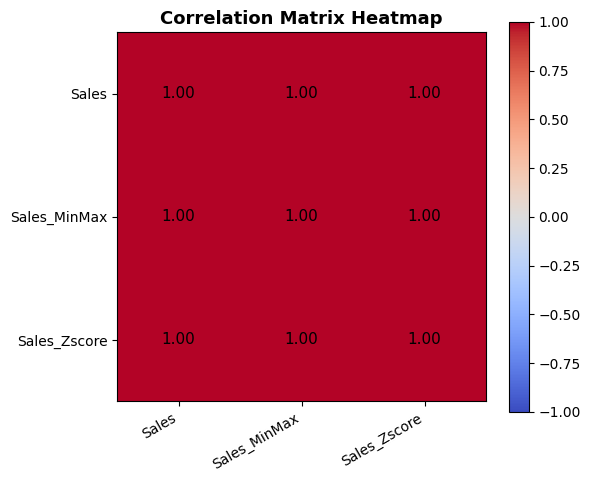

In [84]:
# Visualize correlation matrix as a heatmap (using matplotlib only)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=30, ha='right')
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f'{corr_matrix.values[i, j]:.2f}',
                ha='center', va='center', fontsize=11, color='black')

ax.set_title('Correlation Matrix Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_corr.png', dpi=150)
plt.show()

---
## Summary of Key Insights

| Area | Key Finding |
|---|---|
| **Sales Distribution** | Heavily right-skewed; most orders are under $500, but high-value outliers exist |
| **Seasonality** | Q4 (Oct–Dec) consistently spikes in sales — holiday effect is clear |
| **Top Sub-Category** | Phones and Chairs generate the highest revenue |
| **Regional Split** | West and East regions dominate sales; Central lags |
| **Outliers** | ~10% of sales records are outliers by IQR; removal significantly reduces the mean |
| **Central Tendency** | Mean ($253) > Median ($55) confirms strong right skew |
| **Dispersion** | High variance and std deviation reflect wide spread driven by a few large orders |